In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
def order_points(pts):
    pts = pts.reshape(4, 2).astype(np.float32)

    rect = np.zeros((4, 2), dtype=np.float32)

    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]      # top-left
    rect[2] = pts[np.argmax(s)]      # bottom-right

    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]   # top-right
    rect[3] = pts[np.argmax(diff)]   # bottom-left

    return rect


def warp_paper(image, pts, out_size=(500, 700)):
    if image is None or pts is None:
        return None

    ordered_cords = order_points(pts)

    pts1 = np.float32(ordered_cords)

    w, h = out_size
    pts2 = np.float32([
        [0, 0],      # top-left
        [w, 0],      # top-right
        [w, h],      # bottom-right
        [0, h]       # bottom-left
    ])

    M = cv2.getPerspectiveTransform(pts1, pts2)
    warped = cv2.warpPerspective(image, M, (w, h))

    return warped


def correct_light_and_sharpness(image):
    channels = cv2.split(image)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    equalized_channels = [clahe.apply(ch) for ch in channels]
    equalized_image = cv2.merge(equalized_channels)

    kernel = np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ])

    sharpened_equalized_image = cv2.filter2D(equalized_image, -1, kernel)

    return equalized_image, sharpened_equalized_image


def remove_shadows(warped):
    img = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (21, 21))
    background = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)

    result = cv2.divide(img, background, scale=255)

    result = cv2.adaptiveThreshold( result, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 15, 10 )

    return result

def show_processing_results(original, warped_paper, equalized_image, sharpened_image, shadow_removed_image):
    plt.figure(figsize=(16, 10))

    plt.subplot(151)
    plt.imshow(original[..., ::-1])
    plt.title("Detected Paper")
    plt.axis("off")

    plt.subplot(152)
    plt.imshow(warped_paper[..., ::-1])
    plt.title("Perspective Warped")
    plt.axis("off")

    plt.subplot(153)
    plt.imshow(equalized_image[..., ::-1])
    plt.title("Light Corrected")
    plt.axis("off")

    plt.subplot(154)
    plt.imshow(sharpened_image[..., ::-1])
    plt.title("Sharpened")
    plt.axis("off")

    plt.subplot(155)
    plt.imshow(shadow_removed_image, cmap="gray")
    plt.title("Shadow Removed")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


Corner Points:
[[138. 398.]
 [553. 377.]
 [567. 964.]
 [159. 976.]]


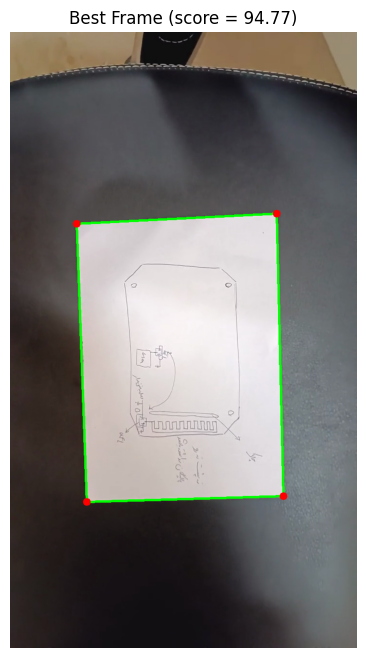

In [3]:
# scenario 1
import cv2
import numpy as np
import matplotlib.pyplot as plt

def angle_between(p1, p2, p0):
    dx1, dy1 = p1[0] - p0[0], p1[1] - p0[1]
    dx2, dy2 = p2[0] - p0[0], p2[1] - p0[1]
    mag1 = (dx1 ** 2 + dy1 ** 2) ** 0.5
    mag2 = (dx2 ** 2 + dy2 ** 2) ** 0.5
    if mag1 * mag2 == 0:
        return 0
    cos_angle = (dx1 * dx2 + dy1 * dy2) / (mag1 * mag2)
    return np.degrees(np.arccos(np.clip(cos_angle, -1, 1)))


def rectangle_score(approx, frame_area):
    area = cv2.contourArea(approx)
    if area < 1500:
        return None

    area_ratio = area / frame_area
    if area_ratio < 0.01 or area_ratio > 0.95:
        return None

    pts = approx.reshape(4, 2).astype(np.float32)

    angle_devs = []
    for i in range(4):
        p0 = pts[i]
        p1 = pts[(i - 1) % 4]
        p2 = pts[(i + 1) % 4]
        ang = angle_between(p1, p2, p0)
        angle_devs.append(abs(90 - ang))
    angle_penalty = float(np.mean(angle_devs))

    if angle_penalty > 35:
        return None

    rect = cv2.minAreaRect(approx)
    (w, h) = rect[1]
    if w == 0 or h == 0:
        return None

    rect_area = w * h
    extent = area / rect_area  

    aspect_ratio = max(w, h) / min(w, h)
    if aspect_ratio > 5:
        return None

    score = (extent * 100) - angle_penalty - (aspect_ratio * 2)
    return score


def find_document_contour(frame):
    height, width = frame.shape[:2]
    new_width = 800
    scale = new_width / width
    new_height = int(height * scale)
    resized = cv2.resize(frame, (new_width, new_height))
    ratio_x = frame.shape[1] / resized.shape[1]
    ratio_y = frame.shape[0] / resized.shape[0]

    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edged = cv2.Canny(blurred, 75, 200)

    kernel = np.ones((5, 5), np.uint8)
    edged = cv2.dilate(edged, kernel, iterations=1)
    edged = cv2.erode(edged, kernel, iterations=1)

    contours, _ = cv2.findContours(edged.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:15]  # کمی بیشتر بررسی کن

    frame_area = resized.shape[0] * resized.shape[1]

    best_approx = None
    best_score = -np.inf

    for contour in contours:
        peri = cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, 0.02 * peri, True)

        if len(approx) != 4:
            continue

        score = rectangle_score(approx, frame_area)
        if score is None:
            continue

        if score > best_score:
            best_score = score
            best_approx = approx

    document_contour = best_approx

    if document_contour is not None:
        document_contour = document_contour.astype(np.float32)
        document_contour[:, 0, 0] *= ratio_x
        document_contour[:, 0, 1] *= ratio_y
        document_contour = document_contour.astype(np.int32)

    if document_contour is not None:
        returned_score = best_score
    else:
        returned_score = -np.inf

    return document_contour, edged, returned_score


cap = cv2.VideoCapture("./videos/video1.mp4")

best_overall_score = -np.inf
best_overall_frame = None
best_overall_contour = None

while True:
    ret, frame = cap.read()
    if not ret:
        break

    contour, edged, score = find_document_contour(frame)
    display = frame.copy()

    if contour is not None:
        cv2.drawContours(display, [contour], -1, (0, 255, 0), 3)

        if score > best_overall_score:
            best_overall_score = score
            best_overall_frame = frame.copy()
            best_overall_contour = contour

    cv2.imshow("Video", display)
    cv2.imshow("Edges", edged)

    key = cv2.waitKey(30) & 0xFF
    if key == ord('q'):
        break
    elif key == ord('p'):
        cv2.waitKey(0)

cap.release()
cv2.destroyAllWindows()

if best_overall_frame is not None:
    corner_points = order_points(best_overall_contour)

    print("Corner Points:")
    print(corner_points)

    best_display = best_overall_frame.copy()
    cv2.drawContours(best_display, [best_overall_contour], -1, (0, 255, 0), 3)

    for point in corner_points:
        x, y = point.astype(int)
        cv2.circle(best_display, (x, y), 8, (0, 0, 255), -1)

    best_display_rgb = cv2.cvtColor(best_display, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(best_display_rgb)
    plt.title(f"Best Frame (score = {best_overall_score:.2f})")
    plt.axis("off")
    plt.show()
else:
    print("no paper found")


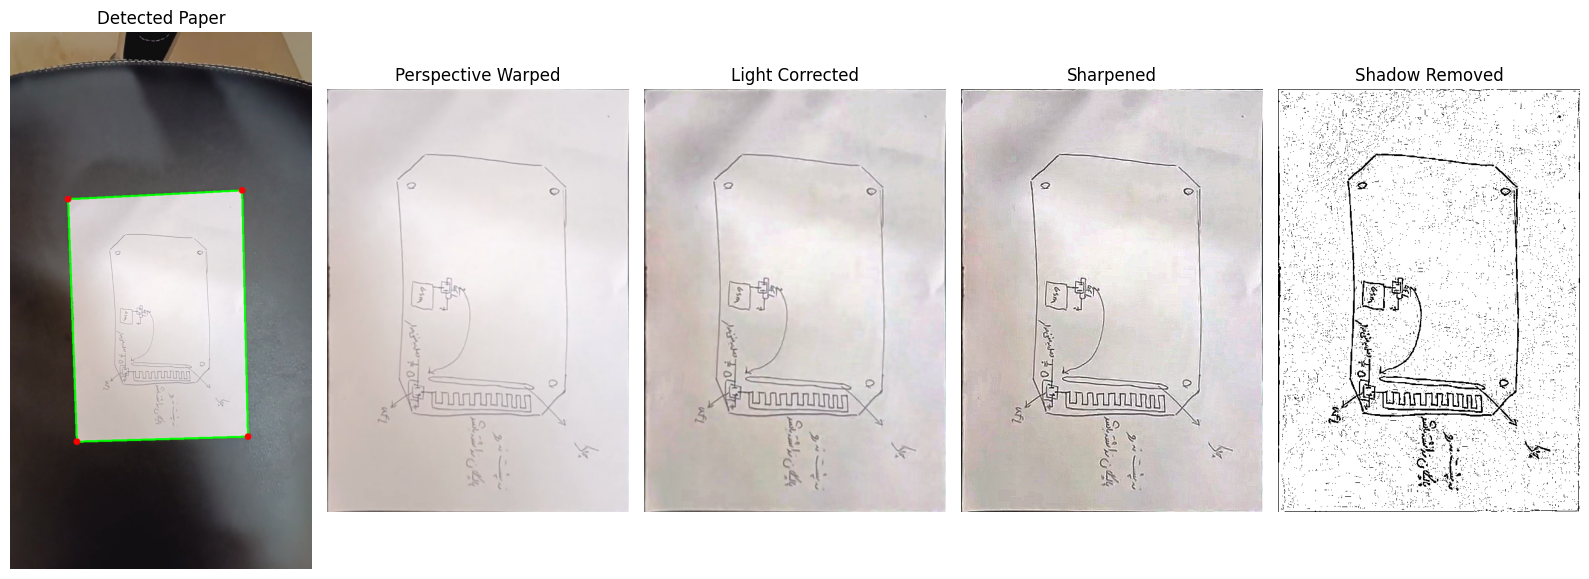

In [4]:
warped_paper = warp_paper(best_overall_frame, corner_points, out_size=(500, 700))

equalized_image, sharpened_image = correct_light_and_sharpness(warped_paper)

shadow_removed_image = remove_shadows(sharpened_image)

show_processing_results( best_display, warped_paper, equalized_image, sharpened_image, shadow_removed_image )

Corner Points:
[[  43.  139.]
 [ 668.  139.]
 [ 668. 1025.]
 [  43. 1025.]]


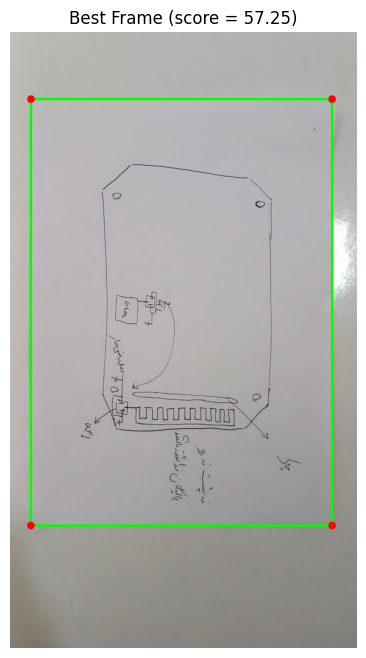

In [5]:
# scenario 2
import cv2
import numpy as np
import matplotlib.pyplot as plt


def rectangle_score(top_left, bottom_right, frame_shape):
    w = bottom_right[0] - top_left[0]
    h = bottom_right[1] - top_left[1]

    if w <= 0 or h <= 0:
        return None

    area = w * h
    frame_area = frame_shape[0] * frame_shape[1]
    area_ratio = area / frame_area

    if area_ratio < 0.01 or area_ratio > 0.95:
        return None

    aspect_ratio = max(w, h) / min(w, h)
    if aspect_ratio > 5:
        return None

    score = (area_ratio * 100) - (aspect_ratio * 2)
    return score


def find_document_corners(frame):
    height, width = frame.shape[:2]
    new_width = 800
    scale = new_width / width
    new_height = int(height * scale)
    resized = cv2.resize(frame, (new_width, new_height))
    ratio_x = frame.shape[1] / resized.shape[1]
    ratio_y = frame.shape[0] / resized.shape[0]

    lab = cv2.cvtColor(resized, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l_eq = clahe.apply(l)

    blurred = cv2.GaussianBlur(l_eq, (5, 5), 0)

    grad_x = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    grad = cv2.magnitude(grad_x, grad_y)
    grad = np.uint8(np.clip(grad, 0, 255))

    _, edged = cv2.threshold(grad, 40, 255, cv2.THRESH_BINARY)

    kernel = np.ones((7, 7), np.uint8)
    edged = cv2.morphologyEx(edged, cv2.MORPH_CLOSE, kernel, iterations=2)

    contours, _ = cv2.findContours(edged.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    h, w = resized.shape[:2]
    frame_area = h * w
    min_contour_area = 0.005 * frame_area  

    valid_contours = []
    for cnt in contours:
        if cv2.contourArea(cnt) > min_contour_area:
            valid_contours.append(cnt)

    top_left = None
    bottom_right = None

    if len(valid_contours) > 0:
        all_pts = []

        for cnt in valid_contours:
            all_pts.append(cnt.reshape(-1, 2))

        all_pts = np.concatenate(all_pts)
        s_all = all_pts[:, 0] + all_pts[:, 1]

        low_thresh = np.percentile(s_all, 1)
        high_thresh = np.percentile(s_all, 99)

        candidates_tl = all_pts[s_all <= low_thresh]
        candidates_br = all_pts[s_all >= high_thresh]

        top_left = candidates_tl[np.argmin(candidates_tl[:, 0] + candidates_tl[:, 1])]
        bottom_right = candidates_br[np.argmax(candidates_br[:, 0] + candidates_br[:, 1])]

        top_left = (int(top_left[0] * ratio_x), int(top_left[1] * ratio_y))
        bottom_right = (int(bottom_right[0] * ratio_x), int(bottom_right[1] * ratio_y))

    return top_left, bottom_right, edged

def get_rectangle_corners(top_left, bottom_right):
    x1, y1 = top_left
    x2, y2 = bottom_right

    corners = np.array([
        [x1, y1],  # top-left
        [x2, y1],  # top-right
        [x2, y2],  # bottom-right
        [x1, y2]   # bottom-left
    ], dtype=np.float32)

    return corners

cap = cv2.VideoCapture("./videos/video4.mp4")

best_overall_score = -np.inf
best_overall_frame = None
best_overall_tl = None
best_overall_br = None

while True:
    ret, frame = cap.read()
    if not ret:
        break

    top_left, bottom_right, edged = find_document_corners(frame)
    display = frame.copy()

    if top_left is not None and bottom_right is not None:
        cv2.rectangle(display, top_left, bottom_right, (0, 255, 0), 3)
        cv2.circle(display, top_left, 8, (255, 0, 0), -1)
        cv2.circle(display, bottom_right, 8, (0, 0, 255), -1)

        score = rectangle_score(top_left, bottom_right, frame.shape)
        if score is not None and score > best_overall_score:
            best_overall_score = score
            best_overall_frame = frame.copy()
            best_overall_tl = top_left
            best_overall_br = bottom_right

    cv2.imshow("Video", display)
    cv2.imshow("Edges", edged)

    key = cv2.waitKey(30) & 0xFF
    if key == ord('q'):
        break
    elif key == ord('p'):
        cv2.waitKey(0)

cap.release()
cv2.destroyAllWindows()

if best_overall_frame is not None:
    corner_points = get_rectangle_corners(best_overall_tl, best_overall_br)

    print("Corner Points:")
    print(corner_points)

    best_display = best_overall_frame.copy()
    cv2.rectangle(best_display, best_overall_tl, best_overall_br, (0, 255, 0), 3)

    for point in corner_points:
        x, y = point.astype(int)
        cv2.circle(best_display, (x, y), 8, (0, 0, 255), -1)

    best_display_rgb = cv2.cvtColor(best_display, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(best_display_rgb)
    plt.title(f"Best Frame (score = {best_overall_score:.2f})")
    plt.axis("off")
    plt.show()
else:
    print("no paper found")


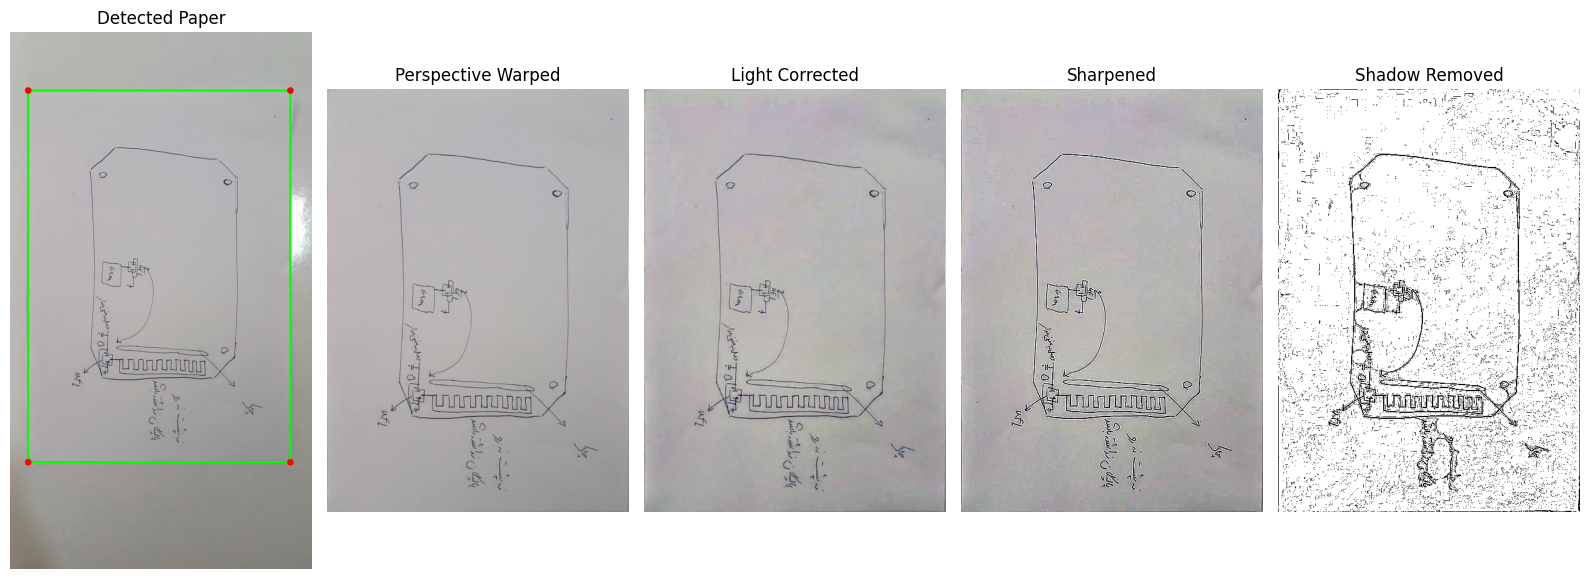

In [6]:
warped_paper = warp_paper(best_overall_frame, corner_points, out_size=(500, 700))

equalized_image, sharpened_image = correct_light_and_sharpness(warped_paper)

shadow_removed_image = remove_shadows(sharpened_image)

show_processing_results( best_display, warped_paper, equalized_image, sharpened_image, shadow_removed_image )

Best Frame Index: 64
Best Component Label: 4
Best Score: 803179.2772964615
Best Rectangle Points:
[[  59  242]
 [ 703  232]
 [ 794 1226]
 [   7 1217]]
Best Lines Count: 58


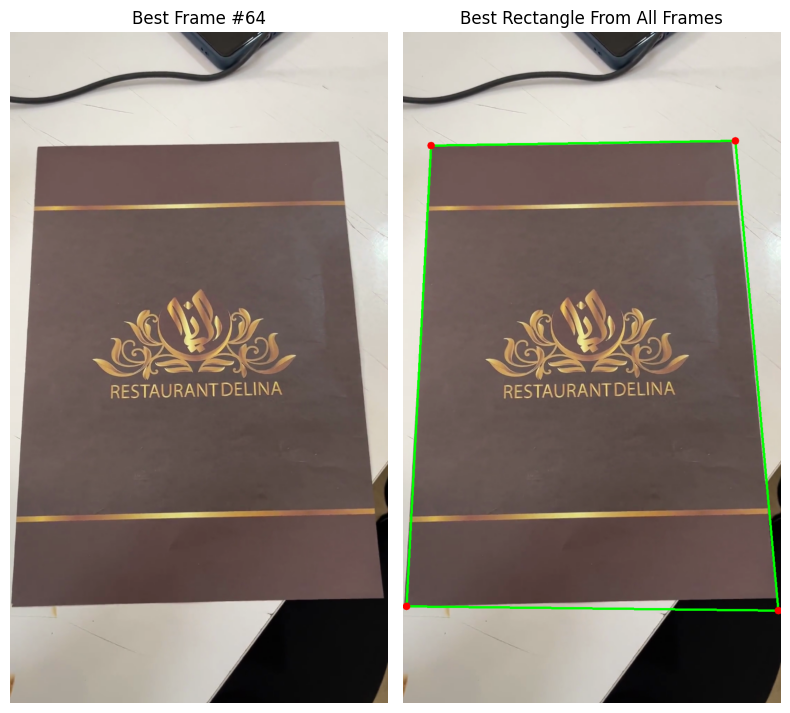

In [9]:
# scenario 3
import cv2
import numpy as np
import matplotlib.pyplot as plt


def normalize_edge_thickness(edged, thickness=3):
    try:
        skeleton = cv2.ximgproc.thinning(edged)
    except AttributeError:
        from skimage.morphology import skeletonize
        skeleton = (skeletonize(edged > 0) * 255).astype(np.uint8)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (thickness, thickness))
    uniform_edges = cv2.dilate(skeleton, kernel, iterations=1)
    return uniform_edges


def find_document_contour(frame, edge_thickness=3):
    resized = cv2.resize(frame, (800, int(frame.shape[0] * 800 / frame.shape[1])))
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    edged = cv2.Canny(blurred, 75, 200)
    edged = normalize_edge_thickness(edged, thickness=edge_thickness)

    return edged, resized


def get_angle(x1, y1, x2, y2):
    angle = np.arctan2(y2 - y1, x2 - x1)
    angle = angle % np.pi
    return angle


def angle_diff_deg(angle1, angle2):
    diff = abs(np.degrees(angle1 - angle2)) % 180
    return min(diff, 180 - diff)


def filter_perpendicular_lines(lines, tolerance_deg=15):
    if lines is None:
        return []

    angles = [get_angle(line[0][0], line[0][1], line[0][2], line[0][3]) for line in lines]

    keep_lines = []

    for i, line in enumerate(lines):
        has_perpendicular = False

        for j in range(len(lines)):
            if i == j:
                continue

            diff = angle_diff_deg(angles[i], angles[j])

            if abs(diff - 90) <= tolerance_deg:
                has_perpendicular = True
                break

        if has_perpendicular:
            keep_lines.append(line)

    return keep_lines


def line_to_abc(line):
    x1, y1, x2, y2 = line[0]

    a = y1 - y2
    b = x2 - x1
    c = x1 * y2 - x2 * y1

    norm = np.sqrt(a * a + b * b)
    if norm == 0:
        return None

    return a / norm, b / norm, c / norm


def intersect_lines(line1, line2):
    abc1 = line_to_abc(line1)
    abc2 = line_to_abc(line2)

    if abc1 is None or abc2 is None:
        return None

    a1, b1, c1 = abc1
    a2, b2, c2 = abc2

    det = a1 * b2 - a2 * b1
    if abs(det) < 1e-6:
        return None

    x = (b1 * c2 - b2 * c1) / det
    y = (c1 * a2 - c2 * a1) / det

    return int(round(x)), int(round(y))


def get_line_center(line):
    x1, y1, x2, y2 = line[0]
    return np.array([(x1 + x2) / 2.0, (y1 + y2) / 2.0])


def get_line_length(line):
    x1, y1, x2, y2 = line[0]
    return np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)


def polygon_area(points):
    points = np.array(points, dtype=np.float32)
    x = points[:, 0]
    y = points[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def is_rectangle_inside_image(points, width, height, margin=20):
    points = np.array(points)

    if np.any(points[:, 0] < -margin):
        return False
    if np.any(points[:, 1] < -margin):
        return False
    if np.any(points[:, 0] > width + margin):
        return False
    if np.any(points[:, 1] > height + margin):
        return False

    return True


def rectangle_score(points, lines, component_area, image_width, image_height):
    points = np.array(points, dtype=np.float32)

    if len(points) != 4:
        return -1

    if not is_rectangle_inside_image(points, image_width, image_height, margin=30):
        return -1

    area = polygon_area(points)
    if area <= 0:
        return -1

    image_area = image_width * image_height
    area_ratio = area / image_area

    if area_ratio < 0.03:
        return -1

    if area_ratio > 0.95:
        return -1

    side_lengths = []

    for i in range(4):
        p1 = points[i]
        p2 = points[(i + 1) % 4]
        side_lengths.append(np.linalg.norm(p2 - p1))

    side_lengths = np.array(side_lengths)

    if np.min(side_lengths) < 30:
        return -1

    width_like = max(side_lengths[0], side_lengths[2])
    height_like = max(side_lengths[1], side_lengths[3])

    aspect_ratio = max(width_like, height_like) / (min(width_like, height_like) + 1e-6)
    if aspect_ratio > 8:
        return -1

    total_line_length = sum(get_line_length(line) for line in lines)
    line_count = len(lines)

    score = 0
    score += area * 1.0
    score += total_line_length * 5.0
    score += line_count * 100.0
    score += component_area * 0.5

    return score


def build_rectangle_from_outer_lines(lines):
    if lines is None or len(lines) < 4:
        return None

    lines = sorted(lines, key=get_line_length, reverse=True)

    angles = np.array([ get_angle(line[0][0], line[0][1], line[0][2], line[0][3]) for line in lines ])

    group1 = []
    group2 = []

    base_angle = angles[0]

    for line, angle in zip(lines, angles):
        diff = angle_diff_deg(base_angle, angle)

        if diff < 45:
            group1.append(line)
        else:
            group2.append(line)

    if len(group1) < 2 or len(group2) < 2:
        return None

    center_all = np.mean([get_line_center(line) for line in lines], axis=0)

    def pick_outer_two(group):
        distances = []

        for line in group:
            x1, y1, x2, y2 = line[0]
            dx = x2 - x1
            dy = y2 - y1

            normal = np.array([-dy, dx], dtype=np.float32)
            normal = normal / (np.linalg.norm(normal) + 1e-6)

            center = get_line_center(line)
            signed_dist = np.dot(center - center_all, normal)
            distances.append(signed_dist)

        min_idx = int(np.argmin(distances))
        max_idx = int(np.argmax(distances))

        return group[min_idx], group[max_idx]

    g1_line_a, g1_line_b = pick_outer_two(group1)
    g2_line_a, g2_line_b = pick_outer_two(group2)

    p1 = intersect_lines(g1_line_a, g2_line_a)
    p2 = intersect_lines(g1_line_a, g2_line_b)
    p3 = intersect_lines(g1_line_b, g2_line_b)
    p4 = intersect_lines(g1_line_b, g2_line_a)

    points = [p1, p2, p3, p4]

    if any(point is None for point in points):
        return None

    points = np.array(points, dtype=np.int32)
    center = np.mean(points, axis=0)

    points = sorted( points, key=lambda p: np.arctan2(p[1] - center[1], p[0] - center[0]) )

    return np.array(points, dtype=np.int32)


def find_best_rectangle_from_all_components(edged):

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats( edged, connectivity=8 )

    image_height, image_width = edged.shape[:2]

    best_rectangle = None
    best_score = -1
    best_label = None
    best_lines = None

    for label_id in range(1, num_labels):
        component_area = stats[label_id, cv2.CC_STAT_AREA]

        if component_area < 80:
            continue

        component_mask = (labels == label_id).astype(np.uint8) * 255

        component_thick = cv2.dilate( component_mask, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)), iterations=1 )

        lines = cv2.HoughLinesP( component_thick, 1, np.pi / 180, threshold=40, minLineLength=20, maxLineGap=50 )

        lines = filter_perpendicular_lines(lines, tolerance_deg=15)

        if len(lines) < 4:
            continue

        rectangle_points = build_rectangle_from_outer_lines(lines)

        if rectangle_points is None:
            continue

        score = rectangle_score( rectangle_points, lines, component_area, image_width, image_height )

        if score > best_score:
            best_score = score
            best_rectangle = rectangle_points
            best_label = label_id
            best_lines = lines

    return best_rectangle, best_score, best_label, best_lines


cap = cv2.VideoCapture("./videos/video5.mp4")

best_frame_score = -1
best_frame_index = -1
best_frame_original = None
best_frame_resized = None
best_frame_rectangle = None
best_component_label = None
best_component_lines = None

frame_index = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    edged, resized_color = find_document_contour(frame, edge_thickness=3)

    rectangle_points, rectangle_score_value, label_id, lines = find_best_rectangle_from_all_components(edged)

    live_rectangle_img = resized_color.copy()

    if rectangle_points is not None:
        cv2.polylines( live_rectangle_img, [rectangle_points], isClosed=True, color=(0, 255, 0), thickness=4 )

        cv2.putText(
            live_rectangle_img,
            f"Frame: {frame_index} | Score: {rectangle_score_value:.0f} | Label: {label_id}",
            (20, 35),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (255, 0, 255),
            2,
            cv2.LINE_AA
        )

        if rectangle_score_value > best_frame_score:
            best_frame_score = rectangle_score_value
            best_frame_index = frame_index
            best_frame_original = frame.copy()
            best_frame_resized = resized_color.copy()
            best_frame_rectangle = rectangle_points.copy()
            best_component_label = label_id
            best_component_lines = lines
    else:
        cv2.putText(
            live_rectangle_img,
            f"Frame: {frame_index} | No rectangle",
            (20, 35),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 0, 255),
            2,
            cv2.LINE_AA
        )

    cv2.imshow("Video", frame)
    cv2.imshow("Detected Rectangles", live_rectangle_img)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

    frame_index += 1



cap.release()
cv2.destroyAllWindows()

if best_frame_resized is not None:
    corner_points = order_points(best_frame_rectangle)

    rectangle_img = best_frame_resized.copy()

    cv2.polylines( rectangle_img, [best_frame_rectangle], isClosed=True, color=(0, 255, 0), thickness=4 )
    
    for point in corner_points:
        x, y = point.astype(int)
        cv2.circle(rectangle_img, (x, y), 8, (0, 0, 255), -1)

    print("Best Frame Index:", best_frame_index)
    print("Best Component Label:", best_component_label)
    print("Best Score:", best_frame_score)
    print("Best Rectangle Points:")
    print(best_frame_rectangle)
    print("Best Lines Count:", len(best_component_lines))

    plt.figure(figsize=(8, 8))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(best_frame_resized, cv2.COLOR_BGR2RGB))
    plt.title(f"Best Frame #{best_frame_index}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(rectangle_img, cv2.COLOR_BGR2RGB))
    plt.title("Best Rectangle From All Frames")
    plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print(" no rectangle found .")


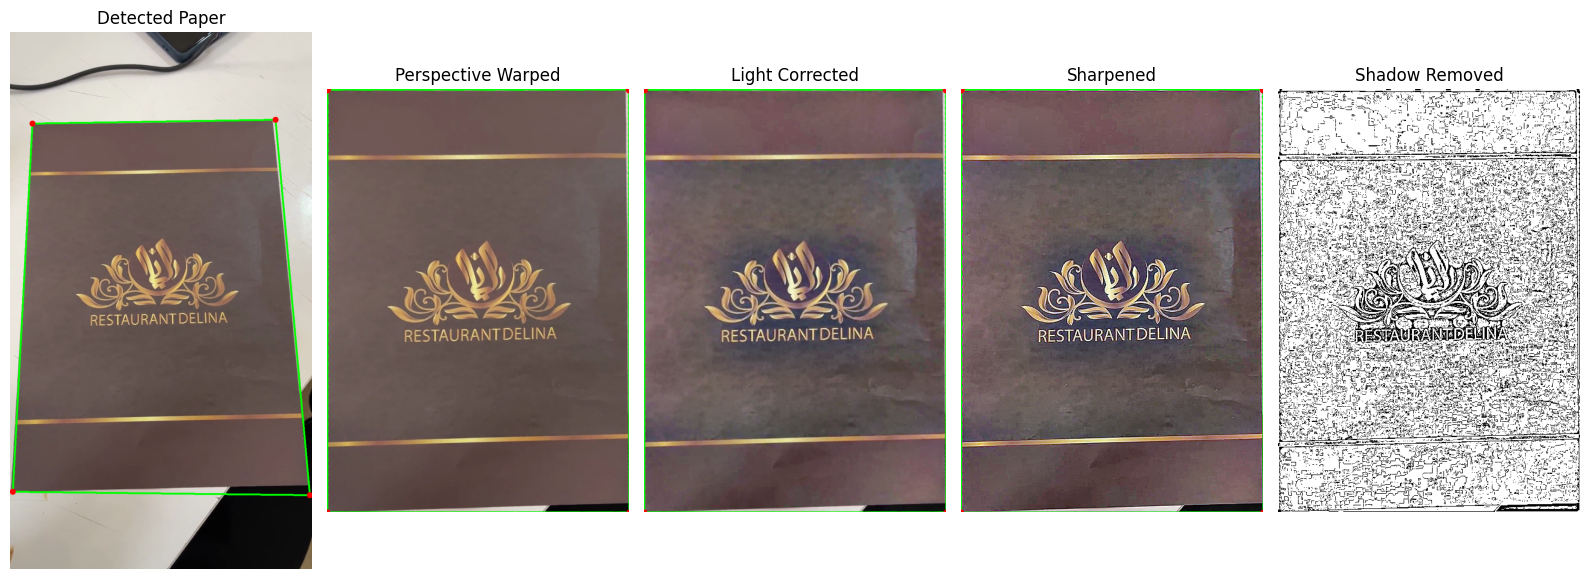

In [10]:
warped_paper = warp_paper(rectangle_img, corner_points, out_size=(500, 700))

equalized_image, sharpened_image = correct_light_and_sharpness(warped_paper)

shadow_removed_image = remove_shadows(sharpened_image)

show_processing_results( rectangle_img, warped_paper, equalized_image, sharpened_image, shadow_removed_image )